# MA934 - Assignment 3

Author: Jabir Hussain (2007942)

---

This assignment looks to explore different gradient descent implementations. It will focus on finding the minimum of a quadratic function and the Rosenbrock function. For the quadratic function, we look for the minimiser of $$f(x) = g(Rx), \text{with } g(y_1, y_2) = \sqrt{b}y_1^2 + 2y_2^2$$ and the rotation matrix $R$ where

$$ R = \begin{bmatrix}
\cos(\phi) & \sin(\phi) \\
-\sin(\phi) & \cos(\phi) 
\end{bmatrix}
$$

The argument $\phi$ is fixed to $\phi = 0.15\pi$, and we will consider both $b = 1, b = 100$. For the iterative scheme, we consider initial considers $x_0 = (-1.2, 1)$ and $x_0 = (2,2)$.

---

## Task 1 - Gradient Descent

This section of the assignment implements gradient descent via $$x_{k+1} = x_k - \alpha \nabla f(x_k)$$
where $\alpha_k > 0$ is the learning rate (step size), and $\nabla f(x_k)$ is the gradient evaluated at iteration $k$.

This method moves from the current term $x_k$ in the direction of steepest descent, $-\nabla f(x_k)$, with the step length $\alpha_k$ controlling the amount that is "travelled" per step. 

The iteration ends either when the gradient norm becomes small, highlighting the program is near a stationary point,
   $$
   |\nabla f(x_k)| < 10^{-3},
   $$

or the iterates stop changing significantly (in turn showing stalled progress),
   $$
   |x_k - x_{k-1}| < 10^{-5}.
   $$

We use the method `gradient_descent_path` to compute the gradient $\nabla f(x_k)$ by applying a user-provided step rule, which then updates the iterator and tracks convergence.

The different algorithms (fixed step, golden section, Nesterov acceleration) are implemented as functions that return a step rule:
$$
(x_{k+1}, \text{ state}) = \text{step\_rule}(x_k, \nabla f(x_k), f, k, \text{ state}).
$$ 

In [256]:
# import necessary libraries
import numpy as np
import matplotlib.pyplot as plt

In [257]:
def gradient_descent_path(f, nabla_f, x0, step_rule,
                          max_iter=10000, grad_tol=1e-3, step_tol=1e-5):
    x = np.array(x0, dtype=float)
    x_prev = None
    state = None
    path = [x.copy()]

    for k in range(max_iter):
        grad = nabla_f(x)

        # stop if gradient small
        if np.linalg.norm(grad) < grad_tol:
            break

        # stop if step barely changes
        if x_prev is not None and np.linalg.norm(x - x_prev) < step_tol:
            break

        x_prev = x.copy()
        x, state = step_rule(x, grad, f, k, state)
        path.append(x.copy())

    return np.array(path)


We will consider a fixed step size, $\alpha_k = L$ for a given argument $L$. This implementation is computationally cheap, but it operates with the assumption that this step size yields valid results across the entire optimisation region.

In [258]:
def step_fixed(L):
    # returns a step rule using constant learning rate
    def step_rule(x, grad, f, k, state):
        return x - L * grad, state
    return step_rule

Golden section search minimises a one-dimensional function on a bounded interval without the use of derivatives:
$$
\min_{\alpha \in [a,b]} \phi(\alpha)
$$

The method uses a contracting bracket $[a,b]$ that always contains a minimiser.
At each iteration, two interior points are chosen so that the ratio of the larger subinterval to the smaller subinterval is constant in the form of the inverse of the golden ratio.
$$
w = \frac{\sqrt{5} - 1}{2} \approx 0.618
$$

This choice ensures that when one interior point is discarded, the remaining point can be reused in the next iteration without recomputing function values, saving computational cost.

We initialize:
$$
\alpha_1 = b - w(b-a), \qquad
\alpha_2 = a + w(b-a),
$$
and evaluate
$$
\phi_1 = \phi(\alpha_1), \qquad
\phi_2 = \phi(\alpha_2).
$$

We then check the conditions of the program: if $\phi_1 < \phi_2$, the minimiser lies in $[a,\alpha_2]$, we set $b=\alpha_2$ and compute a new left interior point. Otherwise the minimiser lies in $[\alpha_1,b]$. We set $a=\alpha_1$ and compute a new right interior point.

At every step, the interval length contracts by the constant factor $w$, guaranteeing uniform convergence.
The process stops when $b-a < \text{tol}$, and the midpoint $\tfrac{1}{2}(a+b)$ is returned as the estimated minimiser.

This implementation uses only one new function evaluation per iteration; all other values are reused.

In [259]:
def golden_section(phi, a=0.0, b=1.0, tol=1e-4):
    # minimise \phi(\alpha) on [a, b] using golden section search
    # returns best \alpha

    w = (np.sqrt(5) - 1) / 2

    alpha_1 = b - w * (b - a)
    alpha_2 = a + w * (b - a)

    phi_1 = phi(alpha_1)
    phi_2 = phi(alpha_2)

    while (b - a) > tol:
        if phi_1 < phi_2:
            b = alpha_2
            alpha_2 = alpha_1
            phi_2 = phi_1
            alpha_1 = b - w * (b - a)
            phi_1 = phi(alpha_1)
        else:
            a = alpha_1
            alpha_1 = alpha_2
            phi_1 = phi_2
            alpha_2 = a + w * (b - a)
            phi_2 = phi(alpha_2)

    return 0.5 * (a + b)

The `step_golden` function implements the Golden Section Search by constructing a one dimensional function
$$\phi(\alpha) = f(x + \alpha d),$$
where $x$ is the current iterate and $d = -\nabla f(x)$ is the direction of descent. It returns a closure called `step_rule` which encapsulates this construction; this closure receives the current iterate $x$, the gradient $\nabla f(x)$, the function $f$, the iteration index $k$, and a state variable. The descent direction is fixed once $x$ is given, so the only remaining variable is the scalar step length $\alpha \ge 0$.

$\phi$ is defined using a Python lambda expression
$$\phi(\alpha) = f(x + \alpha d).$$
The lambda allows $f$ to be evaluated along the ray determined by $x$ and $d$ without constructing a separate named function. Once $\phi$ is defined, the routine calls
$$\alpha = \text{golden\_section}(\phi, 0, \alpha_{\max}, \text{tol}),$$
which approximately minimises $\phi$ on the interval $[0,\alpha_{\max}]$. The resulting update is
$$x_{\text{new}} = x + \alpha d,$$
and the closure returns $(x_{\text{new}},\text{state})$. In this implementation the state is unused and is returned unchanged.

Because the only input to `golden_section` is the scalar function $\phi$, the line search is dimension independent and does not require derivatives of $\phi$. It relies solely on evaluations of the original objective $f$, making the method robust and computationally inexpensive in practice.


In [260]:
def step_golden(alpha_max=1.0, tol=1e-3):
    # returns a step rule using golden section line search
    def step_rule(x, grad, f, k, state):
        direction = -grad
        phi = lambda a: f(x + a * direction)
        alpha = golden_section(phi, 0.0, alpha_max, tol)
        return x + alpha * direction, state
    return step_rule

The `step_nesterov` routine implements Nesterov’s acceleration by introducing another sequence $v_k$ with $x_k$. This sequence updates the point $v_{k+1}$ using standard gradient descent,
$$v_{k+1} = x_k - L \nabla f(x_k),$$
then extrapolates to obtain a corrected term $x_{k+1}$ using the previous auxiliary point $v_k$. This momentum term anticipates future movement and accelerates convergence on smooth problems.

The function `step_nesterov(L)` returns a closure `step_rule` that performs one accelerated update. It receives the current term $x$, the gradient $\nabla f(x)$, the objective function $f$, the iteration index $k$, and a state variable. The state variable holds the previous auxiliary term $v_k$. At the first iteration the state is `None`, so we initialise $v_k$ by setting $v_k = x$.

Inside the closure, the gradient update is computed as
$$v_{k+1} = x - L \nabla f(x),$$
where $L > 0$ is a fixed step length. The new point $x_{k+1}$ is then formed by extrapolating in the direction of $(v_{k+1} - v_k)$ using the coefficient
$$\frac{k}{k+3},$$
that is,
$$x_{k+1} = v_{k+1} + \frac{k}{k+3}(v_{k+1} - v_k).$$

This extrapolation term introduces momentum, allowing the method to progress more aggressively than standard gradient descent. The closure returns the new iterate $x_{k+1}$ together with the updated auxiliary point $v_{k+1}$ as the new state.

Since $v_k$ is stored and reused across iterations, there is no need for additional gradient calculations. As a result, it is marginally more expensive than standard gradient descent while typically converging faster on smooth objective functions.


In [261]:
def step_nesterov(L):
    # returns Nesterov accelerated gradient step rule
    def step_rule(x, grad, f, k, state):
        if state is None:
            v_prev = x
        else:
            v_prev = state

        v_new = x - L * grad
        x_new = v_new + (k / (k + 3)) * (v_new - v_prev)

        return x_new, v_new
    return step_rule

For the quadratic test, let $x = (x_1,x_2)^\top$
and define the rotation
$$
R = 
\begin{pmatrix}
\cos\phi & -\sin\phi\\
\sin\phi & \cos\phi
\end{pmatrix},
\quad \phi = 0.15\pi.
$$

The rotated coordinates are $y = Rx$, where $y = (y_1,y_2)^\top$. In these coordinates the
objective takes the form
$$
f(x)= \sqrt{b}\,y_1^2 + 2y_2^2,
$$
with $b>0$ a scaling parameter. The parameter controls the relative curvature in the two rotated
directions; when $b$ is large the function is steep in the $y_1$ direction and much flatter in the
$y_2$ direction. This creates elliptical level sets and provides a controlled anisotropic test case.

Differentiating with respect to $y$ gives
$$
\nabla_y f =
\begin{pmatrix}
2\sqrt{b}\,y_1\\[2pt]
4\,y_2
\end{pmatrix}.
$$
Since $y = Rx$, the gradient in the original coordinates follows from the chain rule
$$
\nabla_x f = R^\top \nabla_y f.
$$

The minimiser of this function is $x^\star = (0,0)$, but the rotated geometry generates different
convergence behaviours depending on the selected step rule.


In [262]:
def quadratic(x1, x2, b):
    phi = 0.15 * np.pi
    c = np.cos(phi)
    s = np.sin(phi)

    y1 = c * x1 - s * x2
    y2 = s * x1 + c * x2

    return np.sqrt(b) * (y1 * y1) + 2 * (y2 * y2)


def grad_quadratic(x1, x2, b):
    phi = 0.15 * np.pi
    c = np.cos(phi)
    s = np.sin(phi)

    y1 = c * x1 - s * x2
    y2 = s * x1 + c * x2

    dy1 = 2 * np.sqrt(b) * y1
    dy2 = 4 * y2

    grad_x1 = c * dy1 + s * dy2
    grad_x2 = -s * dy1 + c * dy2

    return np.array([grad_x1, grad_x2])


The Rosenbrock function for two variables is defined as
$$
f(x_1,x_2) = (a - x_1)^2 + b,(x_2 - x_1^2)^2,
$$
where $a = 1$ and b takes two values,
$$
b = 1 \quad\text{and}\quad b = 100.
$$

The function has a unique global minimum at
$$
(x_1^*, x_2^*) = (a, a^2) = (1,1),
$$
where $f = 0$.

To compute the gradient, we differentiate each term:

$$
\frac{\partial f}{\partial x_1}
= 2(x_1 - a) - 4 b x_1 (x_2 - x_1^2).
$$

$$
\frac{\partial f}{\partial x_2}
= 2b (x_2 - x_1^2).
$$

Thus the gradient is
$$
\nabla f(x_1,x_2) =
\begin{pmatrix}
2(x_1 - a) - 4 b x_1 (x_2 - x_1^2) \
2b (x_2 - x_1^2)
\end{pmatrix}.$$

In [263]:
def rosenbrock(x1, x2, b, a=1):
    return (a - x1)**2 + b * (x2 - x1**2)**2

def grad_rosenbrock(x1, x2, b, a=1):
    d1 = 2*(x1 - a) - 4*b*x1*(x2 - x1**2)
    d2 = 2*b*(x2 - x1**2)
    return np.array([d1, d2])


The helper function `plot_experiment_subplots` generates a contour plot for each experiment, plotting the path of descent and number of steps taken.

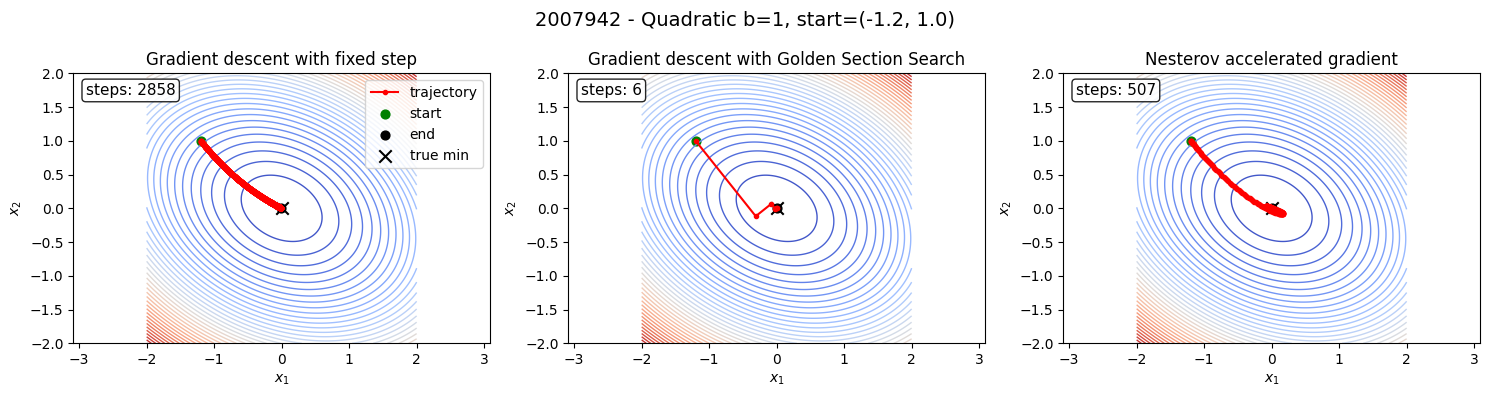

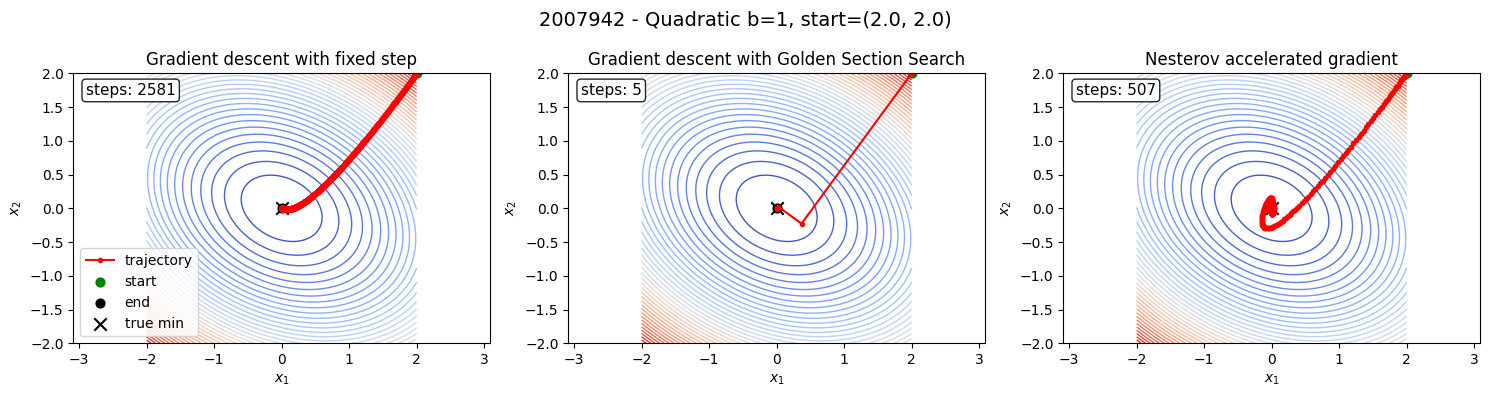

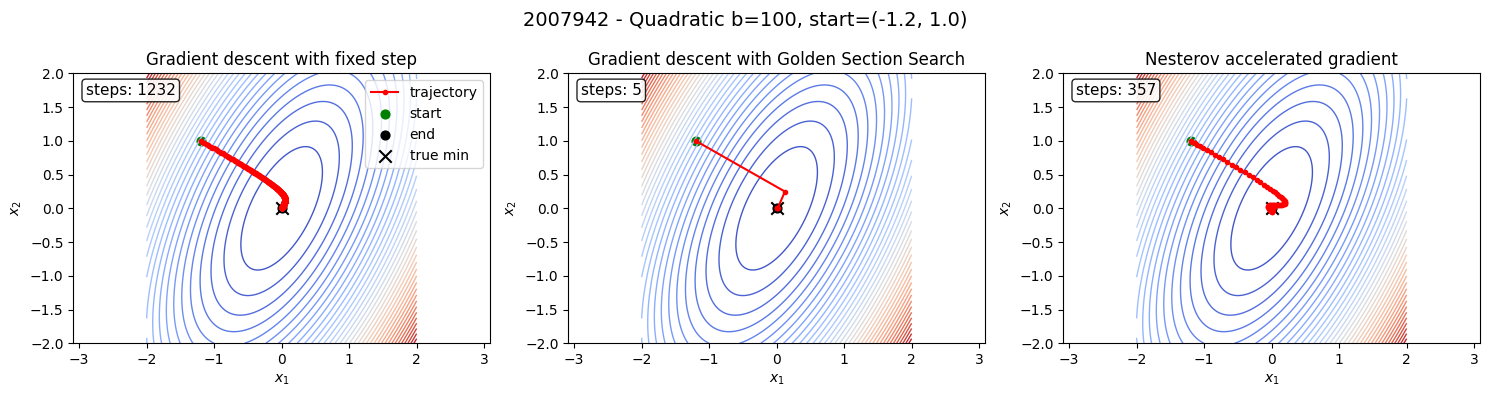

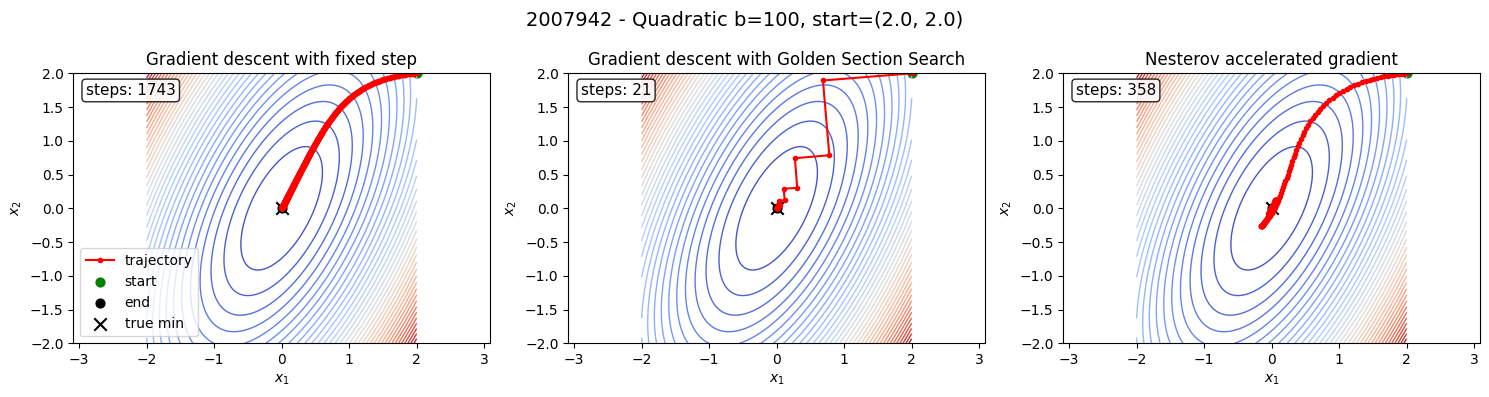

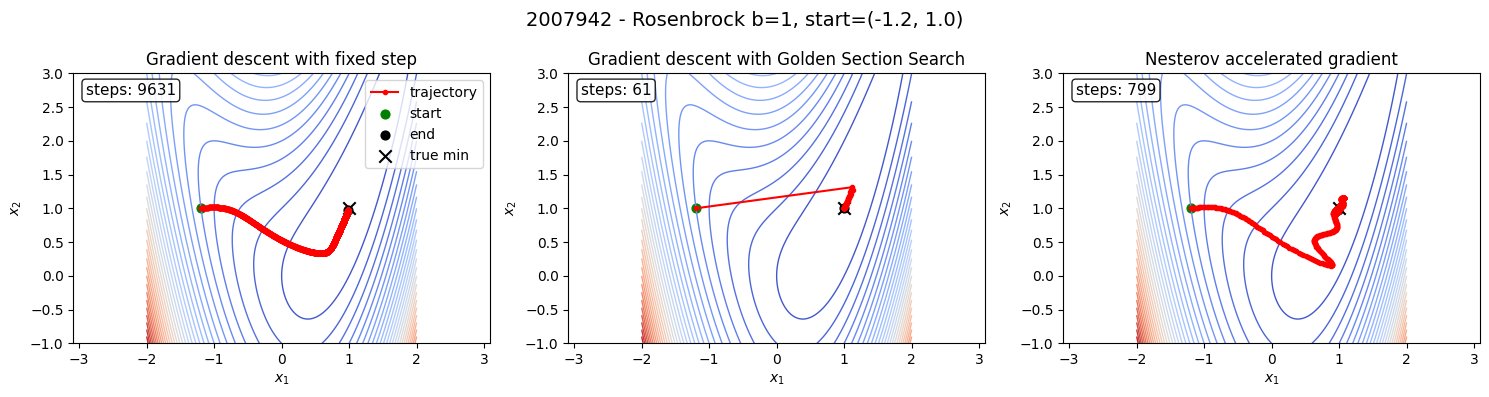

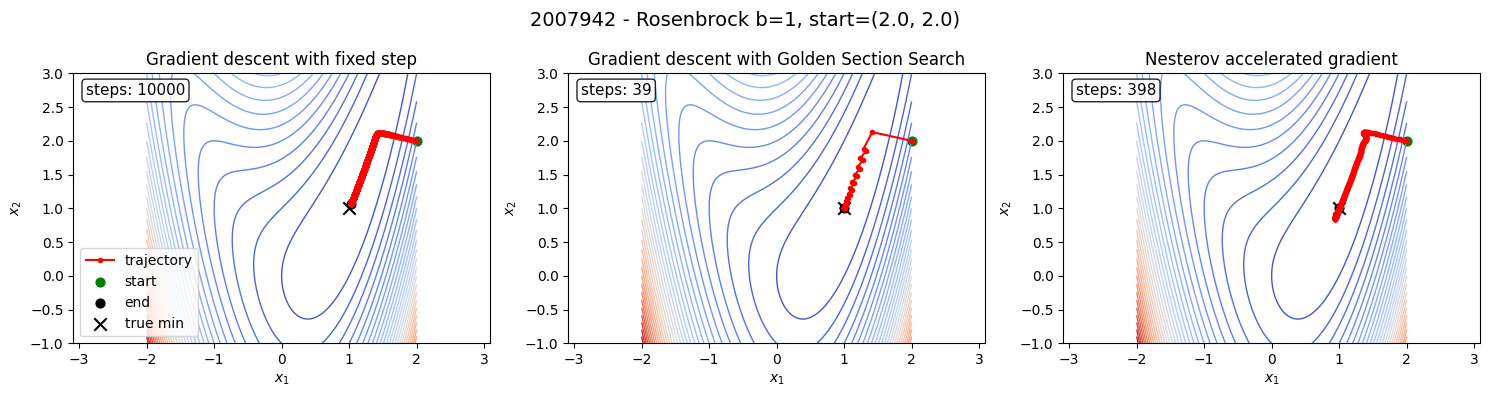

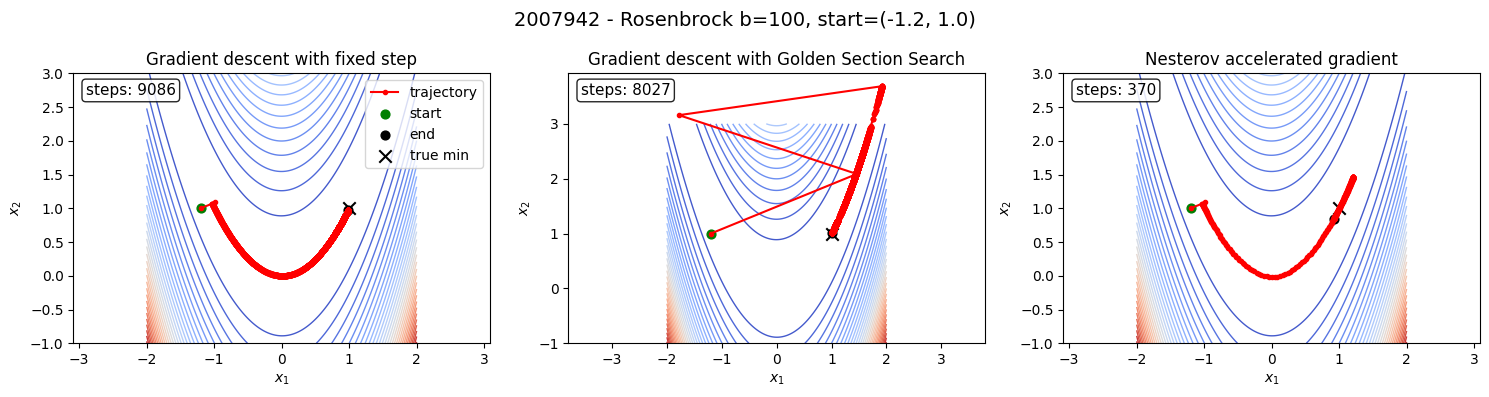

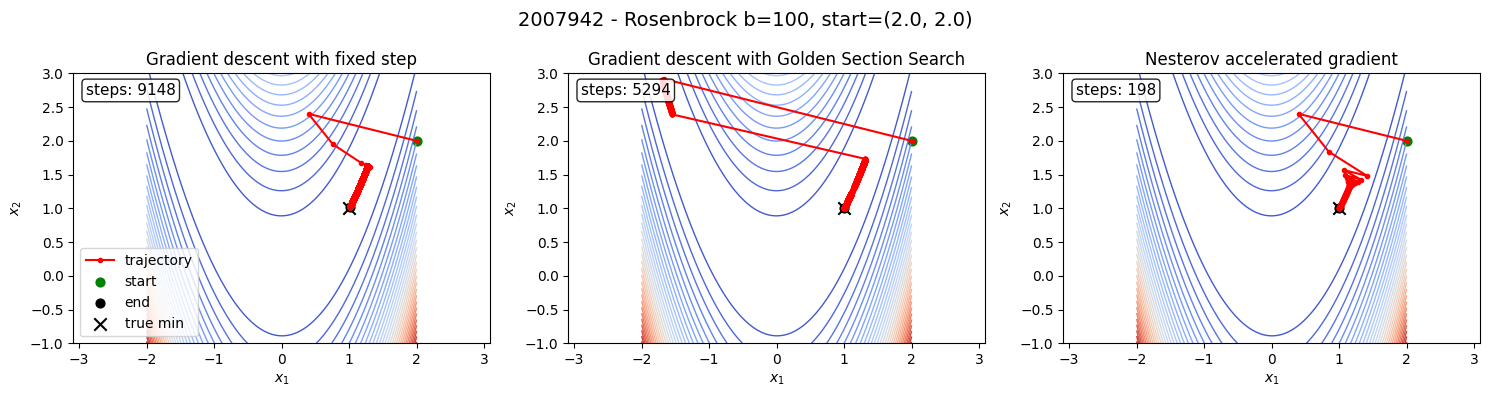

In [ ]:
def plot_experiment_subplots(f, grad_f, x0, b,
                             domain=(-2,2,-2,2),
                             levels=40,
                             x_star=(0.0, 0.0),   # default for quadratic
                             title_prefix="Quadratic"):
    methods = [
        ("Gradient descent with fixed step", step_fixed(1e-3)),
        ("Gradient descent with Golden Section Search", step_golden(alpha_max=1.0)),
        ("Nesterov accelerated gradient", step_nesterov(1e-3)),
    ]

    xmin, xmax, ymin, ymax = domain
    x1 = np.linspace(xmin, xmax, 400)
    x2 = np.linspace(ymin, ymax, 400)
    X1, X2 = np.meshgrid(x1, x2)
    Z = f(X1, X2, b)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for ax, (name, step_rule) in zip(axes, methods):
        path = gradient_descent_path(
            f=lambda x: f(x[0], x[1], b),
            nabla_f=lambda x: grad_f(x[0], x[1], b),
            x0=np.array(x0),
            step_rule=step_rule,
        )
        path = np.array(path)

        ax.contour(X1, X2, Z, levels=levels, cmap="coolwarm", linewidths=1)
        ax.plot(path[:,0], path[:,1], "r.-", label="trajectory")
        ax.scatter(path[0,0], path[0,1], c="green", s=40, label="start")
        ax.scatter(path[-1,0], path[-1,1], c="black", s=40, label="end")

        # show true minimiser
        ax.scatter(x_star[0], x_star[1], marker='x', c='black', s=80, label='true min')

        ax.text(
            0.03, 0.92,
            f"steps: {len(path)-1}",
            transform=ax.transAxes,
            fontsize=11,
            bbox=dict(facecolor='white', alpha=0.85, boxstyle="round,pad=0.25"),
        )
        ax.set_title(name)
        ax.set_xlabel("$x_1$")
        ax.set_ylabel("$x_2$")
        ax.axis("equal")

    fig.suptitle(f"2007942 - {title_prefix} b={b}, start={x0}", fontsize=14)
    axes[0].legend()
    plt.tight_layout()
    plt.show()

starts = [(-1.2, 1.0), (2.0, 2.0)]
bs = [1, 100]

# 1) Quadratic, minimum at (0,0)
for b in bs:
    for x0 in starts:
        plot_experiment_subplots(
            f=quadratic,
            grad_f=grad_quadratic,
            x0=x0,
            b=b,
            domain=(-2, 2, -2, 2),
            levels=40,
            x_star=(0.0, 0.0),
            title_prefix="Quadratic"
        )

# 2) Rosenbrock, a = 1, minimum at (1,1)
for b in bs:
    for x0 in starts:
        plot_experiment_subplots(
            f=rosenbrock,
            grad_f=grad_rosenbrock,
            x0=x0,
            b=b,
            domain=(-2, 2, -1, 3),
            levels=40,
            x_star=(1.0, 1.0),
            title_prefix="Rosenbrock"
        )


The plots above show the path and performance of the different gradient descent implementations for the two test functions, the quadratic and Rosenbrock functions. For the quadratic function, we observe the following:

**Quadratic function evaluation:**
*   For $b = 1$:
    - Fixed step gradient descent: the convergence occurs between ~2500 to ~2800 iterations. The curve is a smooth straight path towards the true minimum. Whilst it correctly finds the minimum, it is a slow solution.
    - Golden Section Search: it requires 5 or 6 iterations, showing an almost ideal method for convergence.
    - Nesterov method: it takes ~500 iterations to reach the true minimum, following a similar path to the fixed step. It slightly overshoots the true value, but stll reaches the true minima significantly faster than the fixed step size.

*   For $b = 100$:
    - Fixed step gradient descent: it converges with around ~1200-1800 iterations, significantly less than the $b=1$ scenario. This is because for $b=100$, the gradient is larger along the axes, so more distance is covered per iteration step.
    - Golden Section Search: it took 5 iterations for $x_0 = (-1.2, 1.0)$ and 21 iterations for $x_0 = (2.0,2.0)$. The zigzag path highlights the change in descent direction at each evaluation point.
    - Nesterov method: it takes ~350 iterations to reach the true minimum. The improvement is not as significant as the case in $b = 1$ as a result of the stretched contours.

**Rosenbrock function evaluation:**
*   For $b = 1$:
    - Fixed step gradient descent: for $x_0 = (-1.2, 1.0)$, it converges after 9631 iterations. For $x_0 = (2.0, 2.0)$, it fails to converge, reaching the maximum iteration tolerance. This behaviour highlights how slowly a fixed step size takes to converge.
    - Golden Section Search: for $x_0 = (-1.2, 1.0)$, it takes 61 iterations as opposed to 39 iterations for $x_0 = (2.0, 2.0)$. This uses significantly less iterations than the fixed step gradient descent method, primarily due to the first iteration which covers a sizeable distance towards the true minima.
    - Nesterov method: for $x_0 = (-1.2, 1.0)$, it takes 799 iterations as opposed to 398 iterations for $x_0 = (2.0, 2.0)$. Similar to the behaviour in $b=1$, Nesterov shows oscillation near the true minima, but reaches it in far less iterations than the fixed step.
*   For $b=100$:
    - Fixed step gradient descent: with 9086 iterations, whilst this method converges, it highlights how fixed step descent struggles for steeper curves.
    - Golden Section Search: for $x_0 = (-1.2, 1.0)$, it takes 8027 iterations as opposed to 5294 iterations for $x_0 = (2.0, 2.0)$. In both cases, the implementation takes adjusts step sizes significantly, showing a jagged path in the plots.
    - Nesterov method: for $x_0 = (-1.2, 1.0)$, it takes 170 iterations as opposed to 398 iterations for $x_0 = (2.0, 2.0)$. In the case of $x_0 = (-1.2, 1.0)$, it shows a significant improvement for speed of convergence. For $x_0 = (2.0, 2.0)$, the plot shows that the Nesterov method does not converge, possibly because this method reaches the gradient tolerance early as a result of Rosenbrock's geometry. 

Whilst the performance evaluation above focuses primarily on the number of iterations required to reach the minima, it should be noted that the Golden Section Search is still computatoinally expensive. Generally, the plots show the iteration count is considerably lower than the other two methods, however at each iteration, the program evaluates $\phi(\alpha) = f(x + \alpha d)$. Thus, despite the lower iteration count, the multiple function calls increase the computational cost.

---

## Task 2 - Constraint Minimisation

Though there are different methods to use constraint minimisation, this task focuses on using box constraints. As per the assignment brief,

> We seek a minimum of $f$ but only for $x$ in an interval $[x_L, x_U]$ i.e. under the constaint that $x_{L, i} < x_i < x_{R, i} \text{ for } i = 1, ..., n.$

The penalty method is a commonly used constraint minimiser. More specificially,
> One approach to handle a problem like $\min_xf(x)$ under the constraints that $g_k(x) \leq 0 \text{ for } k = 1, ..., r$ is the use of a penalty method. Given a penalty function $p(z)$ with $p(z)$ = 0 for $𝑧 < 0$ and $p(z) → ∞$ for $𝑧 → ∞$ and a increasing unbounded sequence $(\mu_l)_l$, consider the sequence of unconstraint minimization problems $$\min_x ( f(x) + \mu_l \sum_{k=1}^r p(g_k(x)))$$

For the lower bound, we know that $x_i \geq x_L$ for validity as $$g_{L, i}(x) = x_L - x_i \leq 0.$$

For the upper bound, we know that $x_i \leq x_U$ as $$g_{U, i}(x) = x_i - x_U \leq 0.$$

Using the penalty function $p(z) = \max(z, 0)^2$, the total penalty is given by the sum of all the constraint violations, given by the expression $$\sum_{i=1}^n p(x_L - x_i) + \sum_{i=1}^n p(x_i - x_U).$$ Applying this to the original problem gives the final equation $$F(x) = f(x) + \mu( \sum_{i=1}^n p(x_L - x_i) + \sum_{i=1}^n p(x_i - x_U) )$$

In [265]:
def penalty(x, xL, xU, q=2):
    lower = np.maximum(xL - x, 0)
    upper = np.maximum(x - xU, 0)
    return np.sum(lower**q + upper**q)

def penalised_func(x, f, xL, xU, mu, q=2):
    return f(x) + mu * penalty(x, xL, xU, q)

The derivatives of the penalty term are given by $$\text{Lower violation }: \frac{d}{dx_i}(x_L - x_i)^2 = 2(x_i - x_L)$$ $$\text{Upper violation }: \frac{d}{dx_i}(x_i - x_U)^2 = 2(x_i - x_U)$$

Masking is used to avoid unnecessary gradient computation, avoiding distorted optimisations whilst reducing computational cost.

In [295]:
def grad_penalty(x, xL, xU, mu, q=2):
    grad = np.zeros_like(x)

    # lower bound - mask only applied for x<xL
    maskL = x < xL
    grad[maskL] += -2 * mu * (xL[maskL] - x[maskL])

    # upper bound - mask only applied for x>xU
    maskU = x > xU
    grad[maskU] += 2 * mu * (x[maskU] - xU[maskU])

    return grad

def penalised_grad(x, grad_f, xL, xU, mu):
    return grad_f(x) + grad_penalty(x, xL, xU, mu)

The `penalty_minimsation` method iterates across different values of $\mu \in {1,5,20,100}$ and for each penalty coefficient $\mu$, is optimises the sequence of optimisation problems in the form $$f(x) + \mu P(x)$$ where $P(x)$ is the penalty terms defined in `grad_penalty` (i.e. `grad[maskL]`).

In [299]:
def penalty_minimisation(f, grad_f, x0, xL, xU, step_rule):
    x = np.array(x0, float)
    full_path = []

    for mu in [1, 5, 20, 100]:
        path = gradient_descent_path(
            f=lambda x_: penalised_func(x_, f, xL, xU, mu),
            nabla_f=lambda x_: penalised_grad(x_, grad_f, xL, xU, mu),
            x0=x,
            step_rule=step_rule,
            max_iter=3000,
            grad_tol=1e-3,
            step_tol=1e-5,
        )
        full_path.extend(path)
        x = path[-1]  # warm start into next μ

    return np.array(full_path)

`plot_penalty_subplots` is a helper function which plots the contours, constraint boxes, gradient descent trajectory and the final position of the trajectory.

In [ ]:
def plot_penalty_subplots(f, grad_f, x0, xL, xU, true_min, title_prefix, domain=(-2,2,-1,3)):
    
    methods = [
        ("Fixed step", step_fixed(1e-3)),
        ("Golden Section Search", step_golden(alpha_max=1.0)),
        ("Nesterov accelerated gradient", step_nesterov(1e-3))
    ]

    # Generate contour grid
    xmin, xmax, ymin, ymax = domain
    x1 = np.linspace(xmin, xmax, 400)
    x2 = np.linspace(ymin, ymax, 400)
    X1, X2 = np.meshgrid(x1, x2)
    grid = np.column_stack([X1.ravel(), X2.ravel()])
    Z = np.array([f(p) for p in grid]).reshape(X1.shape)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for ax, (name, step_rule) in zip(axes, methods):
        path = penalty_minimisation(f, grad_f, x0, xL, xU, step_rule)

        # Contours
        ax.contour(X1, X2, Z, 40, cmap="coolwarm")

        # Constraint box
        ax.axvline(x=xL[0], linestyle="--", color="gray")
        ax.axvline(x=xU[0], linestyle="--", color="gray")
        ax.axhline(y=xL[1], linestyle="--", color="gray")
        ax.axhline(y=xU[1], linestyle="--", color="gray")

        # Path
        ax.plot(path[:,0], path[:,1], "r.-", label="trajectory")

        # Start and end
        ax.scatter(path[0,0], path[0,1], c="green", s=70, label="start")
        ax.scatter(path[-1,0], path[-1,1], c="black", s=70, label="final constrained")

        # True unconstrained min
        ax.scatter(true_min[0], true_min[1], marker='x', color="purple", s=100,
                   label="true unconstrained min")

        ax.set_title(name)
        ax.set_xlabel("$x_1$")
        ax.set_ylabel("$x_2$")
        ax.axis("equal")

    fig.suptitle(f"2007942 - {title_prefix}, Box Constraint Minimisation", fontsize=16)
    plt.tight_layout()
    axes[0].legend()
    plt.show()


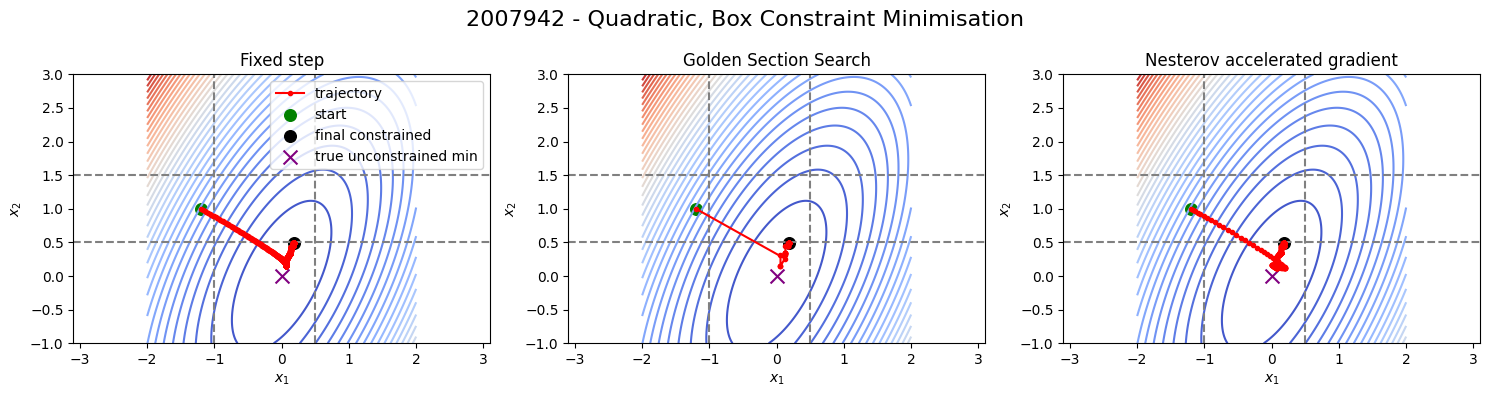

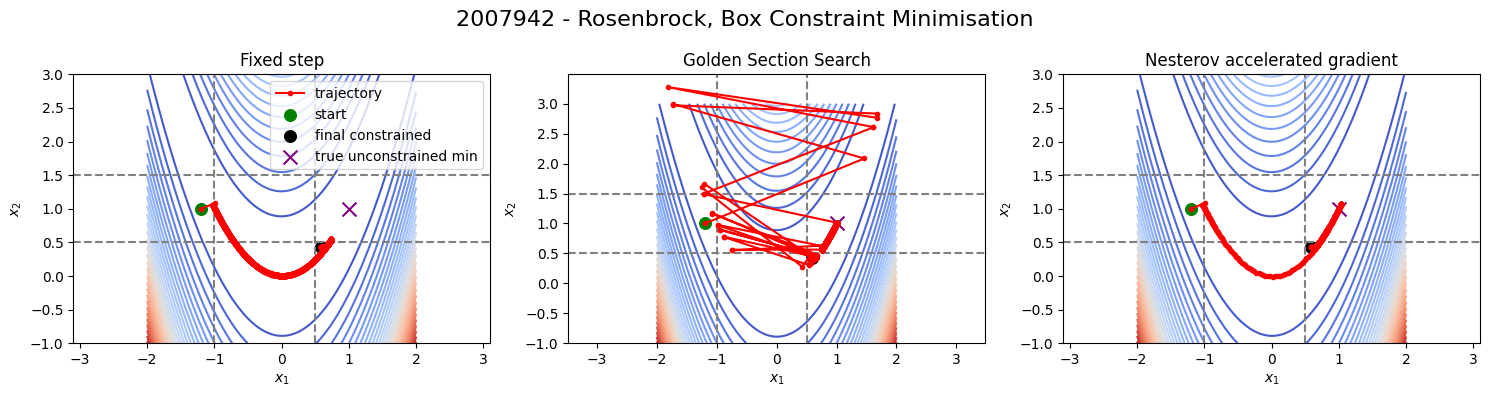

In [301]:
xL = np.array([-1.0, 0.5])
xU = np.array([0.5, 1.5])

plot_penalty_subplots(
    f=lambda x: quadratic(x[0], x[1], b),
    grad_f=lambda x: grad_quadratic(x[0], x[1], b),
    x0=(-1.2, 1),
    xL=xL,
    xU=xU,
    true_min=(0,0),
    title_prefix="Quadratic",
    domain=(-2,2,-1,3)
)

plot_penalty_subplots(
    f=lambda x: rosenbrock(x[0], x[1], b),
    grad_f=lambda x: grad_rosenbrock(x[0], x[1], b),
    x0=(-1.2, 1),
    xL=xL,
    xU=xU,
    true_min=(1,1),
    title_prefix="Rosenbrock",
    domain=(-2,2,-1,3)
)


The first plot highlights the quadratic case; whilst the true solution lies in $(0,0)$, the constrained solution lies around $(0.25, 0.5)$. On the other hand, the Rosenbrock function shows the erratic zigzag behaviour of the Golden Section Search, with the final constrained solution lying around the point $(-0.75, 0.5)$ as opposed to the true minima of $(1,1)$. The optimiser behaves like an unconstrained minimiser within the constraints, performing unnecessary line searches. 

## Task 3 - A Higher Dimensional Application

We will compare the three implementations with the unconstrained Generalised Rosenbrock function, given by the formula $$f(x) = 1 + \sum_{i=2}^n [100(x_i - x_{i-1}^2)^2 + (1-x_{i-1})^2].$$ We calculate the gradient as follows:

Let $$g_i =  100(x_i - x_{i-1}^2)^2 + (1-x_{i-1})^2$$
$$\frac{\partial g_i}{\partial x_i} = 200(x_i - x_{i-1}^2)$$
$$\frac{\partial}{\partial x_{i-1}}100(x_i - x_{i-1}^2)^2 \\
= 100\cdot 2(x_i - x_{i-1}^2)(-2x_{i-1}) \\
= -400x_{i-1}(x_i - x_{i-1}^2)$$

In [ ]:
import numpy as np

def genrose(x):
    x = np.asarray(x, dtype=float)
    xi   = x[1:]
    xim1 = x[:-1]
    return 1.0 + np.sum(100.0 * (xi - xim1**2)**2 + (1.0 - xim1)**2)


def grad_genrose(x):
    x = np.asarray(x, dtype=float)
    n = x.size
    g = np.zeros_like(x)

    g[0] = 2.0 * (x[0] - 1.0) - 400.0 * x[0] * (x[1] - x[0]**2)

    for j in range(1, n-1):
        term_from_prev = 200.0 * (x[j] - x[j-1]**2)
        term_as_prev   = 2.0 * (x[j] - 1.0) - 400.0 * x[j] * (x[j+1] - x[j]**2)
        g[j] = term_from_prev + term_as_prev

    
    g[-1] = 200.0 * (x[-1] - x[-2]**2)

    return g

n = 8
x0 = np.array([-1.2, 1.0] * (n // 2))[:n]
x_star = np.ones(n)

fixed_path = gradient_descent_path(
    f=genrose,
    nabla_f=grad_genrose,
    x0=x0,
    step_rule=step_fixed(1e-3),
)

golden_search = gradient_descent_path(
    f=genrose,
    nabla_f=grad_genrose,
    x0=x0,
    step_rule=step_golden(alpha_max=1.0),
)

nesterov = gradient_descent_path(
    f=genrose,
    nabla_f=grad_genrose,
    x0=x0,
    step_rule=step_nesterov(1e-3),
)

def generate_result(path, f, grad_f, name):
    x_end = path[-1]
    print(f"{name}:")
    # iteration count
    print("Iterations:", len(path))
    # final function value
    print("Final f:", f(x_end))
    # final gradient
    print("Final ||grad||:", np.linalg.norm(grad_f(x_end)))
    # final vector (first 4 dimensions)
    print("Final x first 4 dims:", x_end[:4])
    print()

generate_result(fixed_path, genrose, grad_genrose, "Fixed step")
generate_result(golden_search, genrose, grad_genrose, "Golden Section Search")
generate_result(nesterov, genrose, grad_genrose, "Nesterov Accelerated Gradient")

Fixed step:
Iterations: 8745
Final f: 1.0000986762386246
Final ||grad||: 0.00999435188901632
Final x first 4 dims: [0.99986704 0.9997336  0.99946602 0.99892972]

Golden Section Search:
Iterations: 5754
Final f: 1.0000560342261917
Final ||grad||: 0.008524109851102283
Final x first 4 dims: [0.99990021 0.99979871 0.99959899 0.99919298]

Nesterov Accelerated Gradient:
Iterations: 10001
Final f: nan
Final ||grad||: nan
Final x first 4 dims: [nan nan nan nan]



/var/folders/h9/xtps6rh51x1d5dd3y15qq9c40000gn/T/ipykernel_37885/3714870451.py:19: RuntimeWarning: overflow encountered in scalar multiply
  term_as_prev   = 2.0 * (x[j] - 1.0) - 400.0 * x[j] * (x[j+1] - x[j]**2)
/Users/jabir/msc_env/lib/python3.13/site-packages/numpy/linalg/_linalg.py:2792: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)
/var/folders/h9/xtps6rh51x1d5dd3y15qq9c40000gn/T/ipykernel_37885/3714870451.py:19: RuntimeWarning: overflow encountered in scalar power
  term_as_prev   = 2.0 * (x[j] - 1.0) - 400.0 * x[j] * (x[j+1] - x[j]**2)
/var/folders/h9/xtps6rh51x1d5dd3y15qq9c40000gn/T/ipykernel_37885/3714870451.py:19: RuntimeWarning: invalid value encountered in scalar subtract
  term_as_prev   = 2.0 * (x[j] - 1.0) - 400.0 * x[j] * (x[j+1] - x[j]**2)
/var/folders/h9/xtps6rh51x1d5dd3y15qq9c40000gn/T/ipykernel_37885/3714870451.py:18: RuntimeWarning: overflow encountered in scalar power
  term_from_prev = 200.0 * (x[j] - x[j-1]**2)
/var/folders/h9/xtps6rh51x1d5dd3y

The results above show that the fixed step gradient descent and Golden Section Search implementations converge towards the global minimum $x = [1,1,...,1]$ with a diminishing gradient. Golden Section Search achieves this in ~34.2% less iterations than the fixed step solution, as it will take larger, more calculated step sizes. Nesterov's implementation diverges, with the iteration count reaching its limit and yielding `NaN`'s. O'Donoghue and Candes (
https://doi.org/10.48550/arXiv.1204.3982) offer a solution, using an "adaptive restart scheme." Sadly due to time constraints, I couldn't investigate this further. 

## Task 4

Consider the fixed point iteration
$$x_{k+1} = F(x_k)$$
for some function $F$ with a fixed point $x^*$ where
$$F(x^*) = x^* \quad \text{and} \quad |DF(x)| < q < 1 \quad \text{for } |x - x^*| < d$$
for some $d > 0$. 

1.  Show that if $|x_0 - x^*| < d|$ then $|x_k \rightarrow x^*|$ for $k \rightarrow \infty$.
2.  Show that if $F'(x) = 0$ and $|F''(x)| < M$ for $|x-x^*| < d$ then the convergence of $x_k$ to $x^*$ is at least second order.

**(1)**
$DF(x)$ denotes the derivative in one dimension or the Jacobian in higher dimensions. The condition $|DF(x)| < q < 1$ means that $F$ is a local contraction in a neighbourhood of the fixed point.

We prove that if $|x_0 - x^*| < d$ then $x_k \to x^*$ as $k \to \infty$. 

First we show by induction that $|x_k - x^*| < d \text{  } \forall k$ so that the derivative bound is valid at every step.

We define $e_k = x_k - x^*$.

For $k = 0$ we have $|e_0| = |x_0 - x^*| < d$ by assumption.

Then, we assume that $|e_k| < d$ for some $k$. 

We show that $|e_{k+1}| < d$. Since $x_k$ and $x^*$ lie within distance $d$ of each other, there exists a point $c_k$ between them such that
$$F(x_k) - F(x^*) = F'(c_k)(x_k - x^*)$$
by the Mean Value Theorem. 

Thus, we find that
$$e_{k+1} = F'(c_k)e_k.$$
Since $|e_k| < d$, the point $c_k$ also satisfies the inequality $|c_k - x^*| < d.$ 

Using the derivative bound
$$|F'(c_k)| < q < 1,$$
we find
$$|e_{k+1}| = |F'(c_k)|\,|e_k| < q|e_k| < |e_k| < d.$$
This shows that $|e_{k+1}| < d$ and thus $|x_k - x^*| < d \text{  } \forall k$.

As the derivative bound holds, we can apply the Mean Value Theorem again.
$$e_{k+1} = F'(c_k)e_k$$
with $|F'(c_k)| < q$. 

Thus
$$|e_{k+1}| < q|e_k|.$$
Repeating this gives
$$|e_k| < q^k |e_0|.$$
Because $0 < q < 1$ we have $q^k \to 0$ as $k \to \infty$, hence $e_k \to 0$ and therefore $x_k \to x^*$ as $k \to \infty$. QED.

---

**(2)**
Now, we assume that $F'(x^*) = 0$ and $|F''(x)| < M$ for $|x - x^*| < d$. By the Taylor expansion, we get,
$$F(x) = F(x^*) + F'(x^*)(x - x^*) + \tfrac12 F''(\xi)(x - x^*)^2$$
for some $\xi$ between $x$ and $x^*$. 


Since $F(x^*) = x^*$ and $F'(x^*) = 0$,
$$F(x) - x^* = \tfrac12 F''(\xi)(x - x^*)^2.$$


Using $x = x_k$ yields
$$e_{k+1} = \tfrac12 F''(\xi_k)e_k^2.$$


Taking absolute values and using $|F''(x)| < M$ gives
$$|e_{k+1}| \le \tfrac12 M |e_k|^2.$$


Thus there exists a constant $C = \tfrac12 M$ such that
$$|e_{k+1}| \le C |e_k|^2,$$
which is the condition for convergence of at least second order. QED.

#### An application with Newton's method

Consider a smooth scalar function $f$ and suppose that $x^*$ is a simple root, that is
$$f(x^*) = 0.$$
Newton's method for finding $x^*$ is given by
$$x_{k+1} = x_k - \frac{f(x_k)}{f'(x_k)}.$$
This can be rewritten as a fixed point iteration
$$x_{k+1} = F(x_k)$$
where
$$F(x) = x - \frac{f(x)}{f'(x)}.$$

Firstly, we define that $x^*$ is a fixed point of $F$. As $f(x^*) = 0$ we have
$$F(x^*) = x^* - \frac{f(x^*)}{f'(x^*)} = x^*.$$

Assume that $\exists m > 0$ such that $$ f'(x) > m > 0 \qquad \forall x$$ in a neighbourhood of $x^*$, and $\exists M > 0$ such that $$|f''(x)| < M \qquad \forall x$$ in the region of $x^*$.

By differentiating $F(x) = x - f(x) f'(x)^{-1}$ and simplifying, we get the derivative
$$F'(x) = \frac{f(x) f''(x)}{(f'(x))^2}.$$
Through defining $g(x) = f(x) f''(x)$ and $h(x) = (f'(x))^2$, we substitute these terms in the derivative to get the form
$$F'(x) = \frac{g(x)}{h(x)}.$$

Substituting in the root $x^*$ gives 
$$F'(x^*) = \frac{f(x^*) f''(x^*)}{(f'(x^*))^2} = 0.$$

By continuity of $f$, $f'$, and $f''$, the function $F'$ is continuous near $x^*$.

We also have $f'(x) \ge m > 0$ near $x^*$, thus we know that the denominator in $F'(x)$ is bounded away from zero. 

Since $f(x) \to 0$ as $x \to x^*$ and $f''$ is bounded by $M$ in a neighbourhood of $x^*$, so
$$|F'(x)| = \left|\frac{f(x) f''(x)}{(f'(x))^2}\right| \le \frac{|f(x)| M}{m^2}.$$
Since $f(x) \to 0$ as $x \to x^*$, there exists a neighbourhood of $x^*$ in which
$$|F'(x)| < q < 1$$
for some constant $q$ with $0 < q < 1$. This shows that the derivative of $F$ satisfies the bound required in the fixed point theorem.

Next we consider $F''(x)$. The function $F$ is obtained from $f$, $f'$, and $f''$ by algebraic operations and one division by $f'(x)$, which is bounded away from zero near $x^*$. Since $f$, $f'$, and $f''$ are continuous near $x^*$, it follows that $F''$ is continuous near $x^*$. Thus, there exists a neighbourhood of $x^*$ and a constant $\widetilde M > 0$ such that
$$|F''(x)| < \widetilde M$$
whenever $x$ belongs to this neighbourhood. Thus $F$ also satisfies the second derivative bound required in the second part of the fixed point theorem.

We now apply the result proved earlier for fixed point iterations. The function $F$ satisfies
$$F(x^*) = x^*, \quad |F'(x)| < q < 1, \quad |F''(x)| < \widetilde M$$
for all $x$ in some neighbourhood of $x^*$. 

Thus, for any initial value $x_0$ sufficiently close to $x^*$, the fixed point iteration $x_{k+1} = F(x_k)$ converges to $x^*$ and the errors that follow in the form $e_k = x_k - x^*$ satisfy
$$|e_{k+1}| \le C |e_k|^2$$
for some constant $C > 0$. 

In turn, Newton's method converges to the root $x^*$ with at least second order if the initial guess is chosen close enough to the root. QED.
